In [ ]:
# Correlation is a statistical measure that tells you how strongly two variables are linearly related.
# During Feature Selection based on correlation check two things:
    # Whether Independent features are highly correlated or not with target feature
    # Whether Independent features are highly correlated with each other
# +1 → strong positive relationship
# 0 → no linear relationship
# −1 → strong negative relationship

In [12]:
# Code Example 

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

In [3]:
# Import dataset
Data=pd.read_csv('HousingData.csv')

In [4]:
# Show the shape of the dataset
Data.shape

(506, 14)

In [5]:
# Structure of the dataset
Data.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7


In [6]:
# Basic info of the dataset
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [7]:
# Extract Input and output feature
X=Data.drop(columns='MEDV', axis=1)
y=Data['MEDV']

In [10]:
# Split  the dataset into training and testset
X_train, X_test, y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=2
)

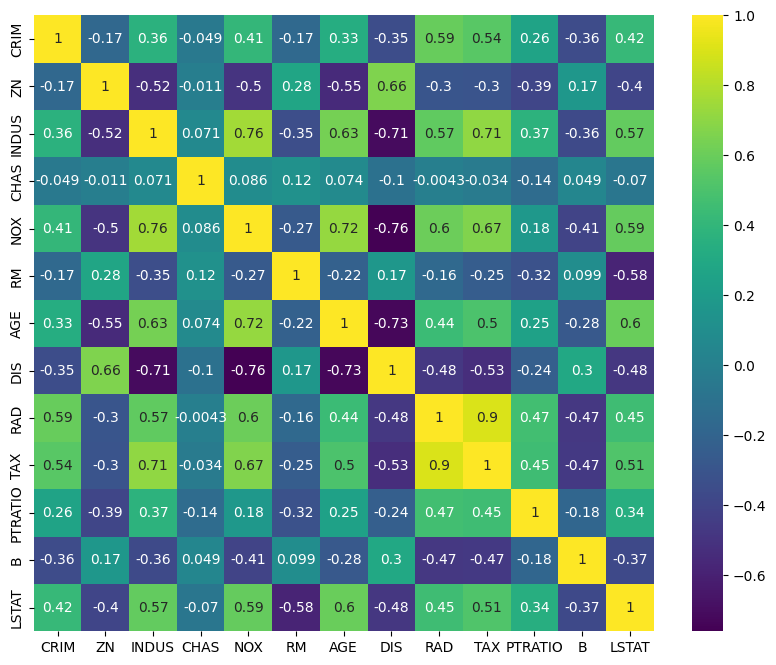

In [ ]:
# Show the correlation of X_train features using heatmap
plt.figure(figsize=(10,8))
corr=X_train.corr()
sns.heatmap(corr, annot=True, cmap='viridis')
plt.show()

In [14]:
# with the following function we can select highly correlated features
# it will remove the first feature that is correlated with anything other feature

def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if (corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [16]:
# Check how many feature correlated with each other
corr_features = correlation(X_train, 0.7)
len(set(corr_features))
corr_features

{'AGE', 'NOX', 'TAX'}